In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import csv
import sys
import os

subset_data_path = Path("../../data/processed/restaurants_philadelphia.csv")

df = pd.read_csv(subset_data_path)

with open(subset_data_path, mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    for i, row in enumerate(reader):
        if i < 5:
            print(row)
        else:
            break

['business_id', 'name', 'city', 'state', 'latitude', 'longitude', 'stars', 'review_count', 'categories', 'attributes', 'is_open']
['MTSW4McQd7CbVtyjqoe9mw', 'St Honore Pastries', 'Philadelphia', 'PA', '39.9555052', '-75.1555641', '4.0', '80', 'Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries', '{\'RestaurantsDelivery\': \'False\', \'OutdoorSeating\': \'False\', \'BusinessAcceptsCreditCards\': \'False\', \'BusinessParking\': "{\'garage\': False, \'street\': True, \'validated\': False, \'lot\': False, \'valet\': False}", \'BikeParking\': \'True\', \'RestaurantsPriceRange2\': \'1\', \'RestaurantsTakeOut\': \'True\', \'ByAppointmentOnly\': \'False\', \'WiFi\': "u\'free\'", \'Alcohol\': "u\'none\'", \'Caters\': \'True\'}', '1']
['MUTTqe8uqyMdBl186RmNeA', 'Tuna Bar', 'Philadelphia', 'PA', '39.953949', '-75.1432262', '4.0', '245', 'Sushi Bars, Restaurants, Japanese', '{\'RestaurantsReservations\': \'True\', \'RestaurantsGoodForGroups\': \'True\', \'RestaurantsAttire\': "\'casual\'", \'Bu

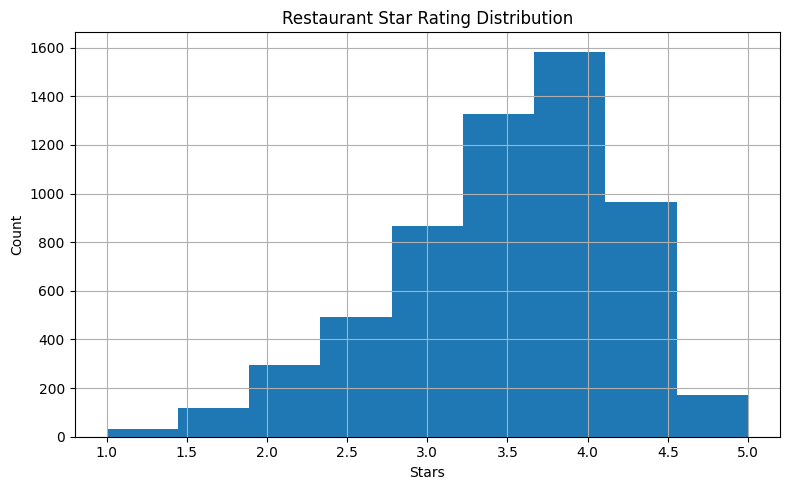

In [8]:
def plot_star_distribution(df: pd.DataFrame):
    plt.figure(figsize=(8, 5))
    df["stars"].dropna().hist(bins=9)
    plt.title("Restaurant Star Rating Distribution")
    plt.xlabel("Stars")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


plot_star_distribution(df)
    

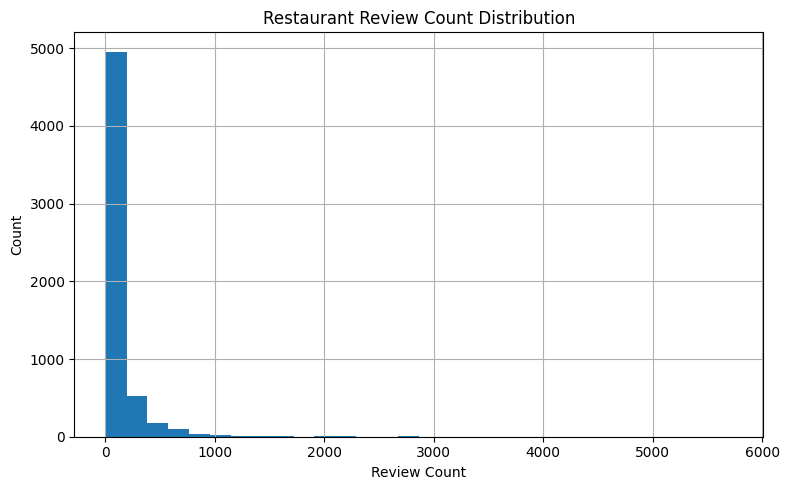

In [7]:
def plot_review_count_distribution(df: pd.DataFrame):
    plt.figure(figsize=(8, 5))
    df["review_count"].dropna().hist(bins=30)
    plt.title("Restaurant Review Count Distribution")
    plt.xlabel("Review Count")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



plot_review_count_distribution(df)


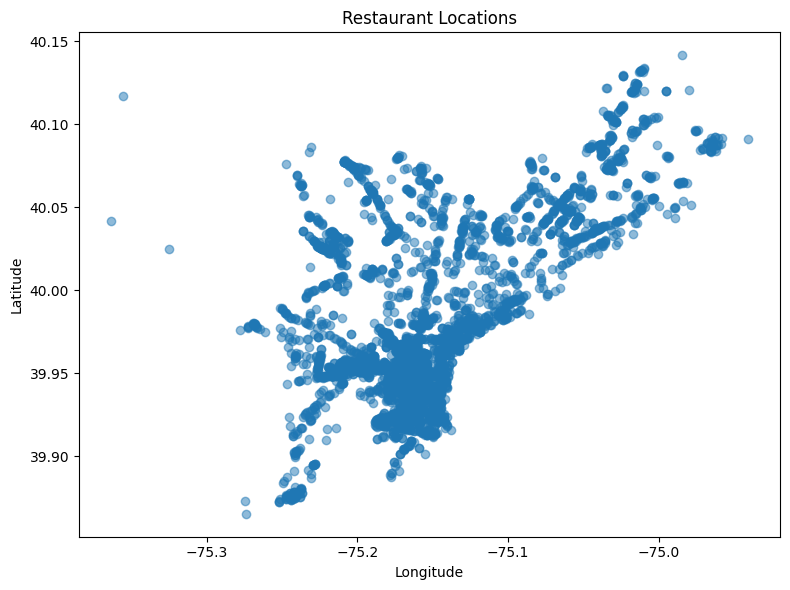

In [6]:
def plot_location_scatter(df: pd.DataFrame):
    plt.figure(figsize=(8, 6))
    plt.scatter(df["longitude"], df["latitude"], alpha=0.5)
    plt.title("Restaurant Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()


plot_location_scatter(df)


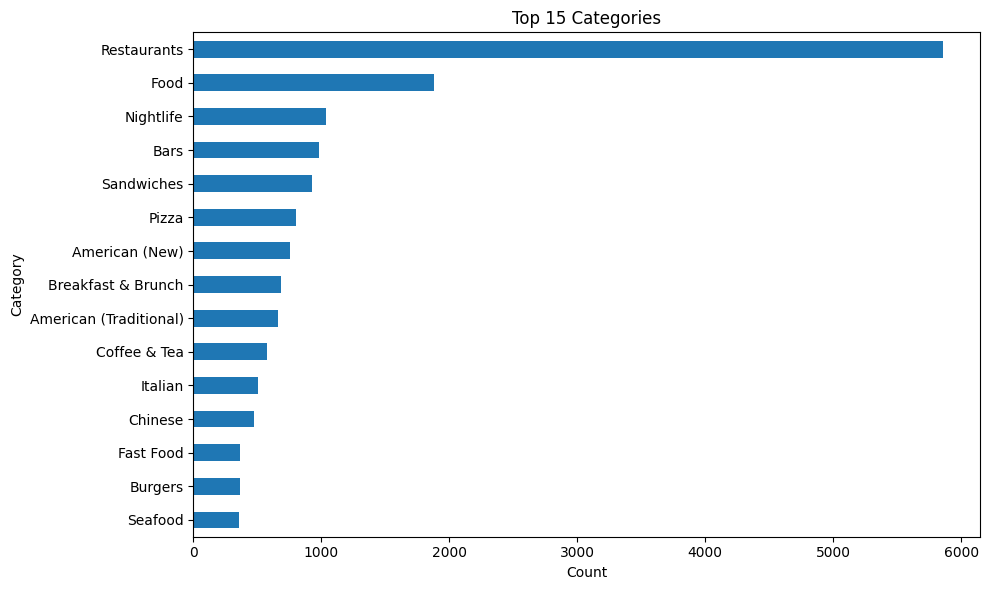

In [5]:
def plot_top_categories(df: pd.DataFrame, top_n: int = 15):
    categories_series = (
        df["categories"].dropna().str.split(", ").explode().value_counts().head(top_n)
    )

    plt.figure(figsize=(10, 6))
    categories_series.sort_values().plot(kind="barh")
    plt.title(f"Top {top_n} Categories")
    plt.xlabel("Count")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
    
plot_top_categories(df)
